* this notebook uses parallel job division to allow the HPC to run the script faster on multiple CPU's

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Fluctuator, Trajectory
from joblib import Parallel, delayed

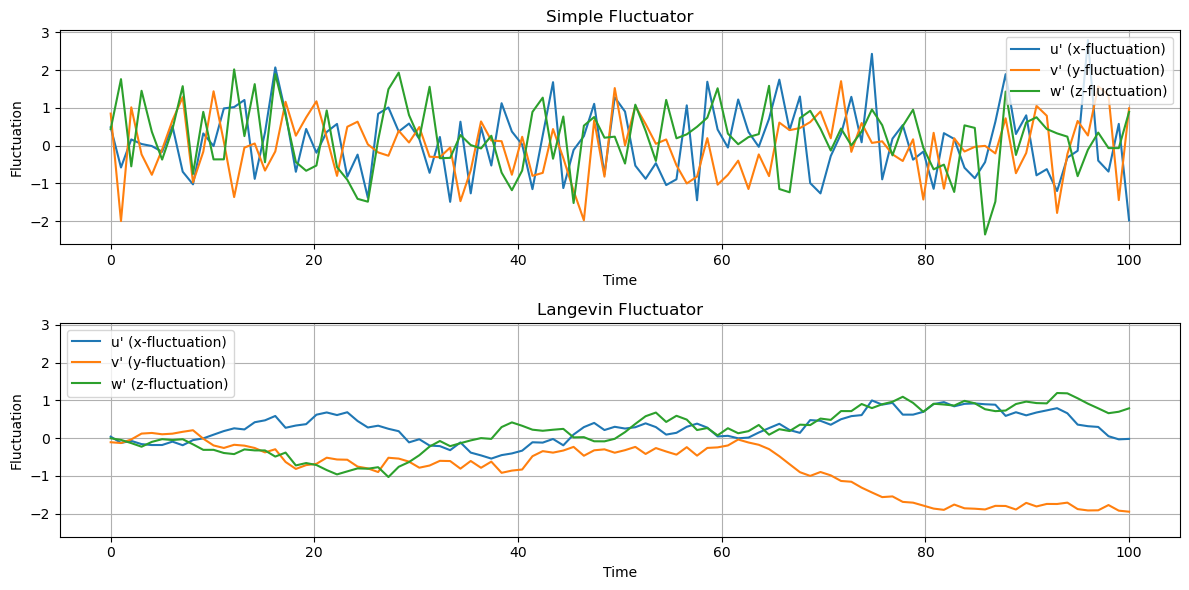

In [ ]:
# visualize the temporal fluctuation profiles
simple_fluc = Fluctuator(method='simple', dt=0.01)
langevin_fluc = Fluctuator(method='langevin', dt=0.01, C0=2.1) 

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharey=True)
simple_fluc.plot(ax=axs[0])
axs[0].set_title('Simple Fluctuator')
langevin_fluc.plot(ax=axs[1])
axs[1].set_title('Langevin Fluctuator')
plt.tight_layout()
plt.show()

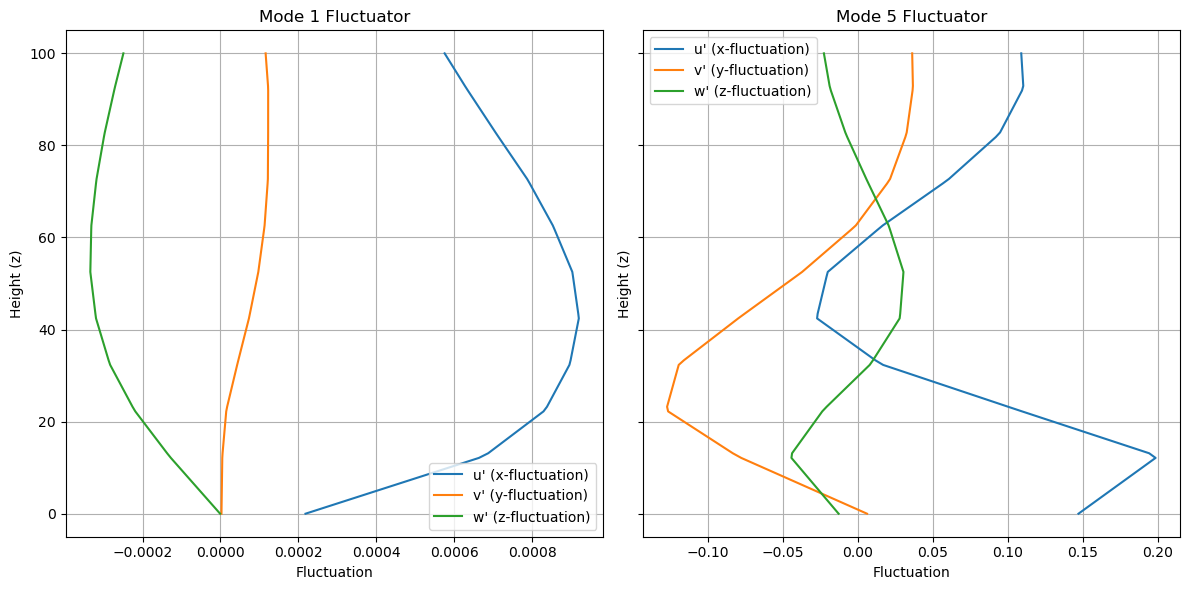

In [13]:
# visualize the spatial fluctuation profiles
mode1_fluc = Fluctuator(method='pod', n_modes=1)
mode5_fluc = Fluctuator(method='pod', n_modes=5) 

fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
mode1_fluc.plot(ax=axs[0])
axs[0].set_title('Mode 1 Fluctuator')
mode5_fluc.plot(ax=axs[1])
axs[1].set_title('Mode 5 Fluctuator')
plt.tight_layout()
plt.show()

Synthesizing wind field with parameters: z_height=100, direction=0, U_ref=8, z0=0.03, z_ref=10


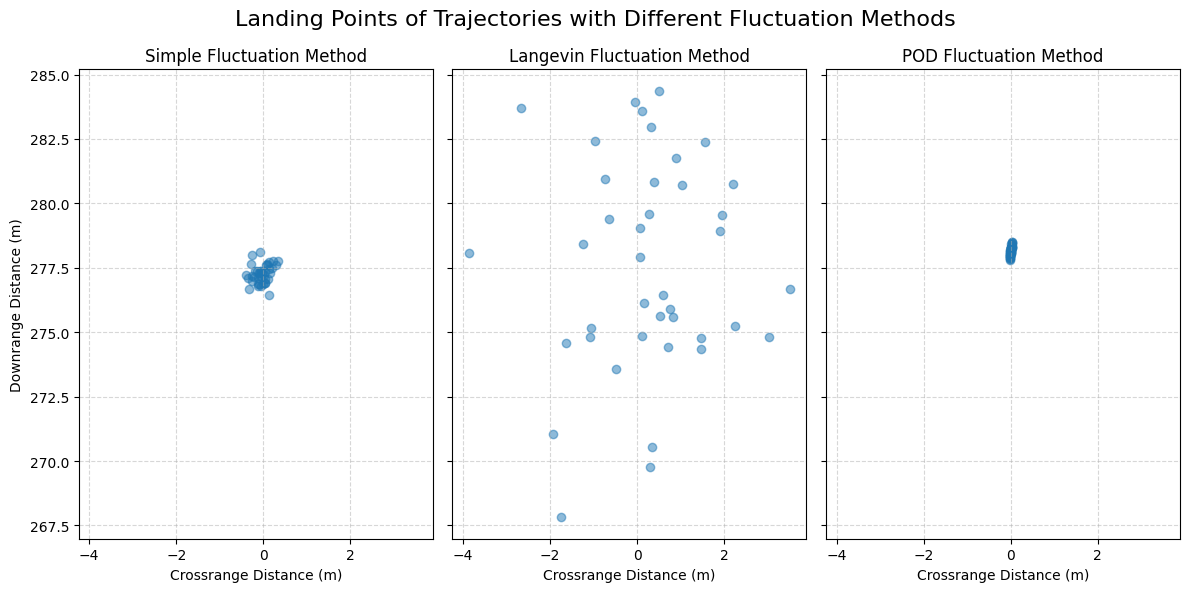

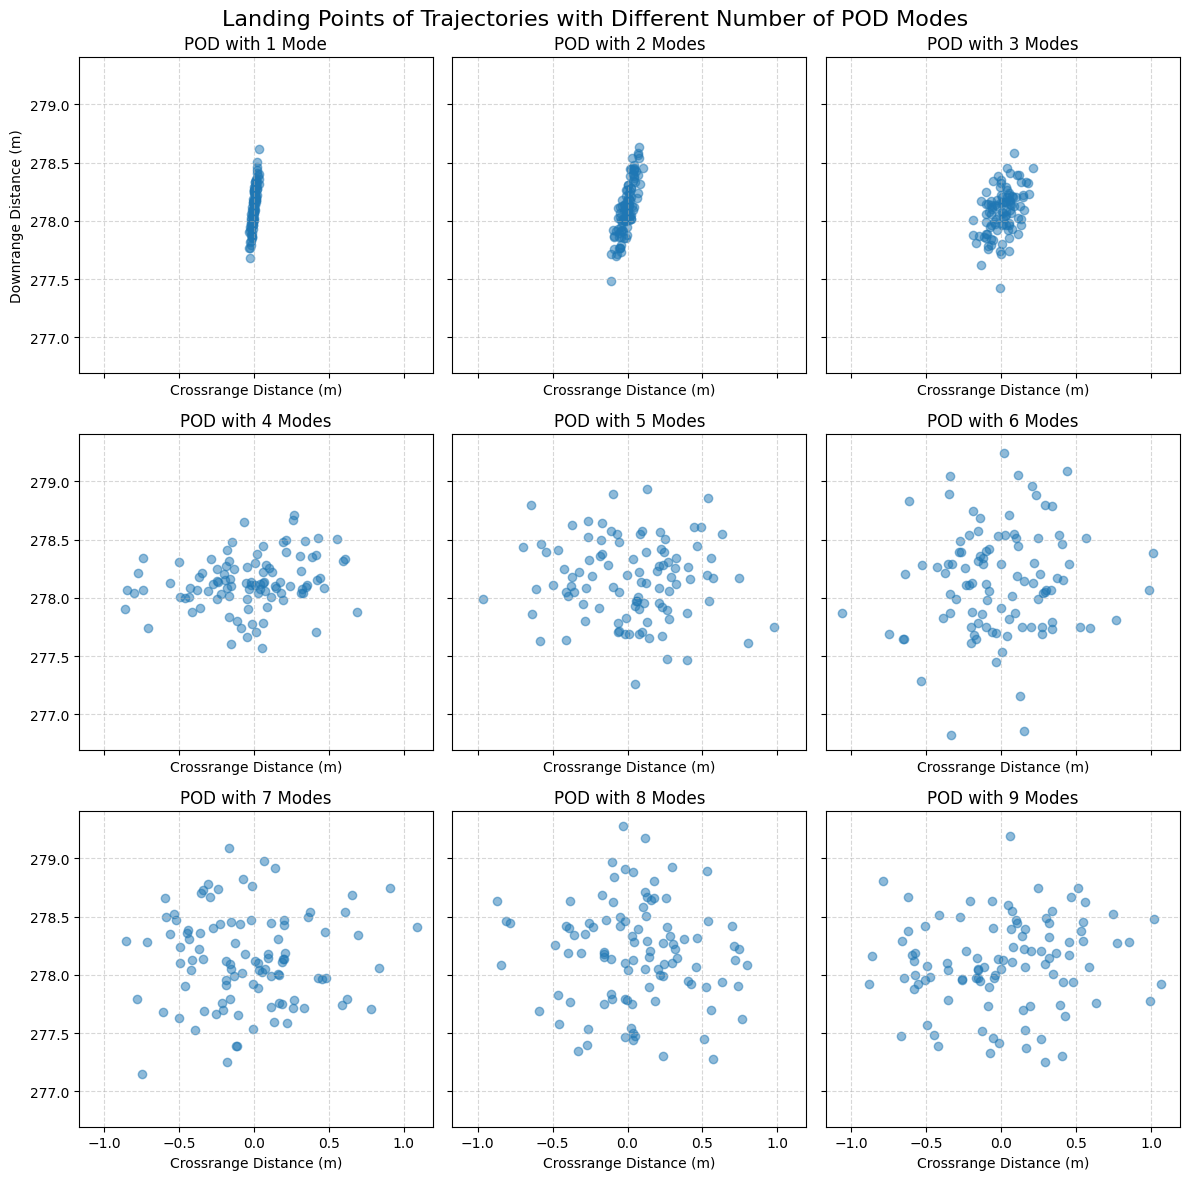

In [4]:
# Add fluctuations to the wind
wind = WindField(profile='log', U_ref=8, z_ref=10, z0=0.03, direction=0)

methods = ['Simple', 'Langevin', 'POD']

landing_points1 = {method: [] for method in methods}

for method in methods:
    for i in range(40):
        fluc = Fluctuator(method=method, dt=0.01, C0=2.1, cf=1.0, n_modes=1) # settings can be adjusted as needed
        traj = Trajectory(
            ball_speed=76, 
            launch_angle=13, 
            spin_rate=2500,
            wind=wind,
            fluc=fluc
        )
        if method == 'POD':
            traj.solve('rk45')
        else:
            traj.solve('euler')
        landing_points1[method].append(traj.p[-1][:2])

fig, axs = plt.subplots(1,3,figsize=(12, 6), sharey=True, sharex=True)
for i, method in enumerate(methods):
    points = np.array(landing_points1[method])
    
    axs[i].scatter(points[:, 1], points[:, 0], alpha=0.5)
    axs[i].set_title(f'{method[0].upper() + method[1:]} Fluctuation Method')
    axs[i].set_xlabel('Crossrange Distance (m)')
    axs[i].grid(True, which='both', linestyle='--', alpha=0.5)
axs[0].set_ylabel('Downrange Distance (m)')
plt.suptitle('Landing Points of Trajectories with Different Fluctuation Methods', fontsize=16)
plt.tight_layout()
plt.show()
modes = range(1,10)

landing_points_modes = {mode: [] for mode in modes}

for mode in modes:
    for i in range(100):
        fluc = Fluctuator(method='POD', dt=0.01, C0=2.1, cf=1.0, n_modes=mode) # settings can be adjusted as needed
        traj = Trajectory(
            ball_speed=76, 
            launch_angle=13, 
            spin_rate=2500,
            wind=wind,
            fluc=fluc
        )
        
        traj.solve('rk45')
        landing_points_modes[mode].append(traj.p[-1][:2])
fig, axs = plt.subplots(3,3,figsize=(12, 12), sharey=True, sharex=True)

for i, mode in enumerate(modes):
    points = np.array(landing_points_modes[mode])
    
    row, col = divmod(i, 3)
    axs[row, col].scatter(points[:, 1], points[:, 0], alpha=0.5)
    axs[row, col].set_title(f'POD with {mode} Mode{"s" if mode > 1 else ""}')
    axs[row, col].set_xlabel('Crossrange Distance (m)')
    axs[row, col].grid(True, which='both', linestyle='--', alpha=0.5)
axs[0, 0].set_ylabel('Downrange Distance (m)')
plt.suptitle('Landing Points of Trajectories with Different Number of POD Modes', fontsize=16)  
plt.tight_layout()
plt.show()

In [18]:
# 1. Define a helper function for a single run
def simulate_single_shot(method, wind, **kwargs):
    # Re-initialize or pass objects safely inside the worker
    fluc = Fluctuator(method=method, **kwargs)
    traj = Trajectory(
        ball_speed=76, 
        launch_angle=13, 
        spin_rate=2500,
        wind=wind,
        fluc=fluc
    )
    if method == 'POD':
        traj.solve('rk45')
    else:
        traj.solve('euler')
    return traj.p[-1][:2]

# Compare landing positions for differnt fluctuators

In [24]:
wind = WindField(profile='log', U_ref=8, z_ref=10, z0=0.03, direction=0)

methods = ['Simple', 'Langevin', 'POD']

landing_points = {method: [] for method in methods}

# 3. Run in parallel across your allocated HPC cores
# n_jobs=-1 will automatically use ALL cores you requested via bsub
for method in methods:
    results = Parallel(n_jobs=-1)(
        delayed(simulate_single_shot)(method=method, wind=wind) for _ in range(100)
    )
    landing_points[method] = results

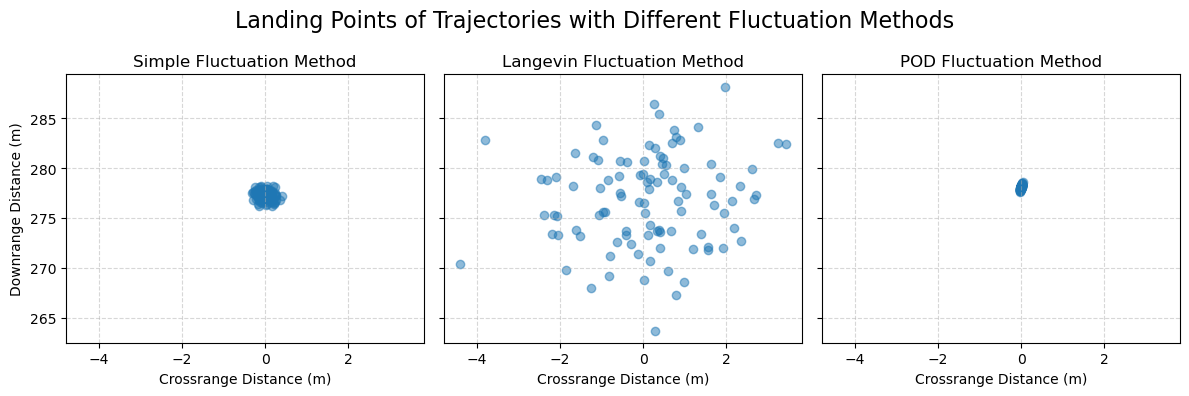

In [25]:
fig, axs = plt.subplots(1,3,figsize=(12, 4), sharey=True, sharex=True)

for i, method in enumerate(methods):
    points = np.array(landing_points[method])
    
    axs[i].scatter(points[:, 1], points[:, 0], alpha=0.5)
    axs[i].set_title(f'{method[0].upper() + method[1:]} Fluctuation Method')
    axs[i].set_xlabel('Crossrange Distance (m)')
    axs[i].grid(True, which='both', linestyle='--', alpha=0.5)
axs[0].set_ylabel('Downrange Distance (m)')
plt.suptitle('Landing Points of Trajectories with Different Fluctuation Methods', fontsize=16)
plt.tight_layout()
plt.show()

# Compare n_modes in 3x3

In [26]:
# 2. Set up your parameters
modes = range(1, 10)
wind = WindField(profile='log', U_ref=8, z_ref=10, z0=0.03, direction=0)

landing_points_modes = {mode: [] for mode in modes}

# 3. Run in parallel across your allocated HPC cores
# n_jobs=-1 will automatically use ALL cores you requested via bsub
for mode in modes:
    results = Parallel(n_jobs=-1)(
        delayed(simulate_single_shot)(method='POD', n_modes=mode, wind=wind) for _ in range(20)
    )
    landing_points_modes[mode] = results

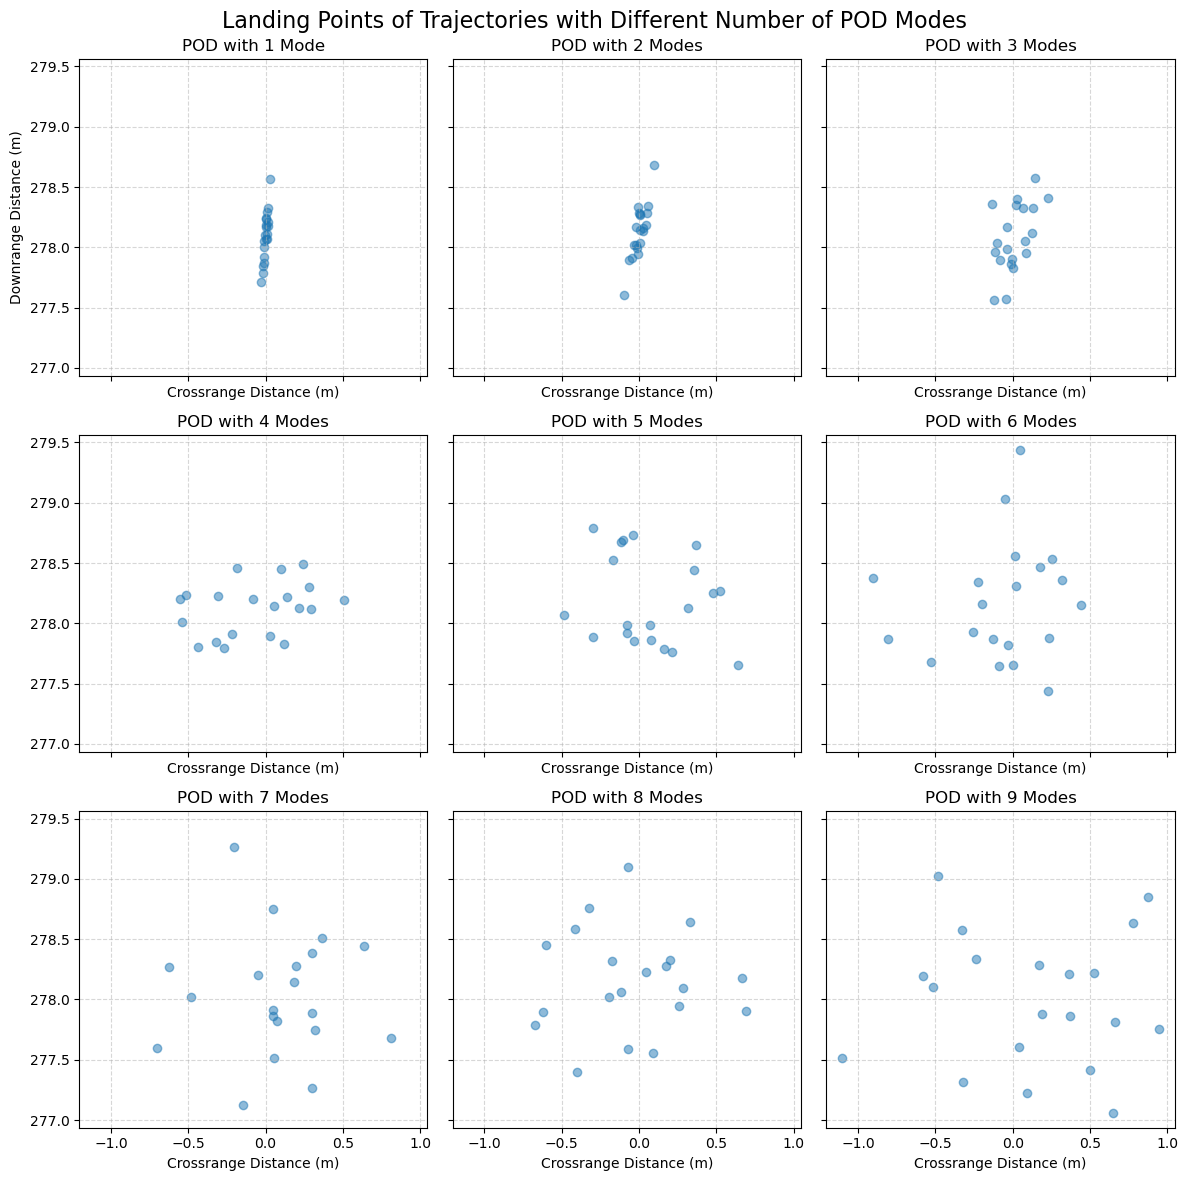

In [27]:
fig, axs = plt.subplots(3,3,figsize=(12, 12), sharey=True, sharex=True)
for mode in modes:
    points = np.array(landing_points_modes[mode])
    
    row, col = divmod(mode-1, 3)
    axs[row, col].scatter(points[:, 1], points[:, 0], alpha=0.5)
    axs[row, col].set_title(f'POD with {mode} Mode{"s" if mode > 1 else ""}')
    axs[row, col].set_xlabel('Crossrange Distance (m)')
    axs[row, col].grid(True, which='both', linestyle='--', alpha=0.5)
axs[0, 0].set_ylabel('Downrange Distance (m)')
plt.suptitle('Landing Points of Trajectories with Different Number of POD Modes', fontsize=16)  
plt.tight_layout()
plt.show()